In [2]:
import sys
print(sys.executable)

/Users/test/Documents/music-artist-insights/.venv/bin/python


In [3]:
import duckdb
print(duckdb.__version__)

1.5.5


In [4]:
from pathlib import Path
import duckdb
import pandas as pd

DB_PATH = Path("../music_artist_insights.duckdb")

con = duckdb.connect(str(DB_PATH), read_only=True)

print("Connected to DuckDB")

Connected to DuckDB


In [5]:
tables = con.execute("""
    SHOW TABLES
""").fetchdf()

tables

,name
0,gold_artist_insights
1,gold_lastfm_audience_metrics
2,gold_release_metrics
3,lastfm_artist_profile
4,lastfm_artist_tags
5,lastfm_audience_snapshots
6,lastfm_similar_artists
7,release_catalogue


In [6]:
release_yearly = con.execute("""
    SELECT *
    FROM gold_release_metrics
    ORDER BY release_year
""").fetchdf()

release_yearly

,release_year,total_releases,core_releases,singles,albums,eps,remixes,compilations,dj_mixes,live_releases,previous_year_releases,yoy_release_change,yoy_release_pct,comparable_ytd_releases,comparable_ytd_core_releases,dataset_through_date
0,1996,1,1,1,0,0,0,0,0,0,<NA>,<NA>,NaN,1,1,2026-09-25
1,1999,3,1,2,1,0,1,1,1,0,1,2,200.0,2,1,2026-09-25
2,2000,3,1,1,2,0,0,2,2,0,3,0,0.0,3,1,2026-09-25
3,2001,1,1,1,0,0,0,0,0,0,3,-2,-66.7,1,1,2026-09-25
4,2002,1,1,1,0,0,0,0,0,0,1,0,0.0,1,1,2026-09-25
5,2003,6,5,1,2,3,0,1,1,1,1,5,500.0,4,4,2026-09-25
6,2004,6,2,2,4,0,0,4,3,1,6,0,0.0,5,2,2026-09-25
7,2005,10,7,4,4,2,0,3,2,0,6,4,66.7,7,5,2026-09-25
8,2006,8,5,4,3,1,0,3,2,0,10,-2,-20.0,3,2,2026-09-25
9,2007,9,4,4,5,0,0,5,3,1,8,1,12.5,7,4,2026-09-25


In [7]:
release_yearly[
    [
        "total_releases",
        "core_releases",
        "singles",
        "albums",
        "eps",
        "remixes",
        "compilations",
        "dj_mixes",
        "live_releases"
    ]
].describe().round(1)

,total_releases,core_releases,singles,albums,eps,remixes,compilations,dj_mixes,live_releases
count,29.0,29.0,29.0,29.0,29.0,29.0,29.0,29.0,29.0
mean,18.2,9.2,10.3,6.8,1.0,3.1,5.4,3.0,0.6
std,11.9,7.4,8.7,4.7,1.7,3.2,4.2,1.9,0.8
min,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,8.0,4.0,3.0,4.0,0.0,0.0,3.0,2.0,0.0
50%,20.0,7.0,9.0,6.0,0.0,2.0,5.0,3.0,0.0
75%,30.0,16.0,19.0,9.0,2.0,6.0,7.0,4.0,1.0
max,35.0,26.0,26.0,18.0,8.0,10.0,18.0,9.0,4.0


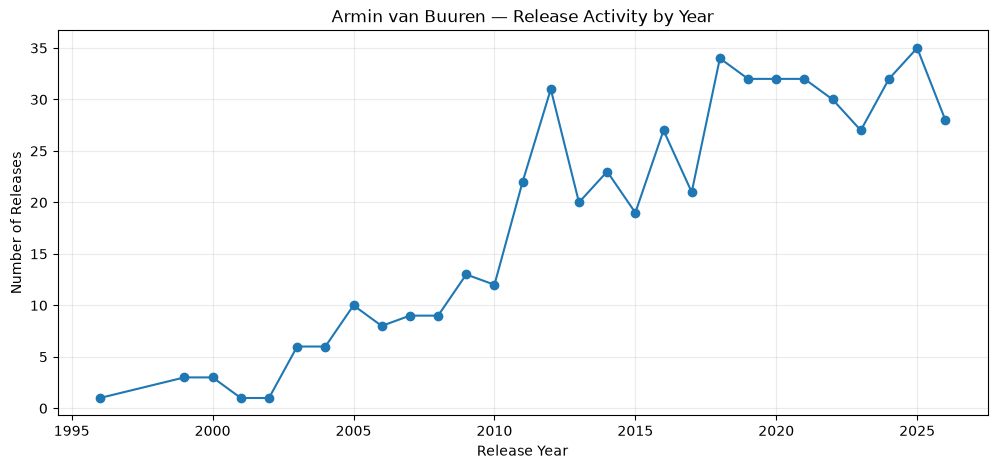

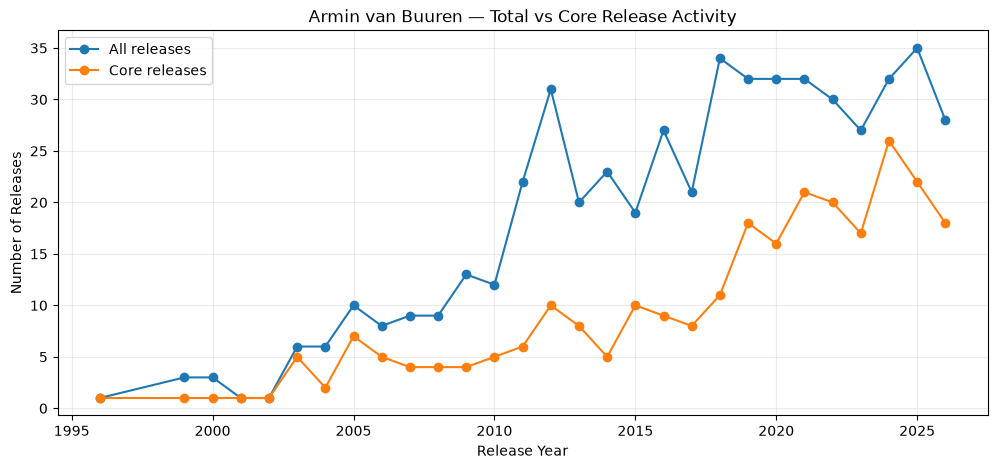

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    release_yearly["release_year"],
    release_yearly["total_releases"],
    marker="o"
)

plt.title("Armin van Buuren — Release Activity by Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Releases")
plt.grid(alpha=0.25)

plt.show()

plt.figure(figsize=(12, 5))

plt.plot(
    release_yearly["release_year"],
    release_yearly["total_releases"],
    marker="o",
    label="All releases"
)

plt.plot(
    release_yearly["release_year"],
    release_yearly["core_releases"],
    marker="o",
    label="Core releases"
)

plt.title("Armin van Buuren — Total vs Core Release Activity")
plt.xlabel("Release Year")
plt.ylabel("Number of Releases")
plt.legend()
plt.grid(alpha=0.25)

plt.show()

## Release Mix Over Time

Total release activity increased substantially across Armin van Buuren's career.
The next step is to identify which release types are responsible for that growth.

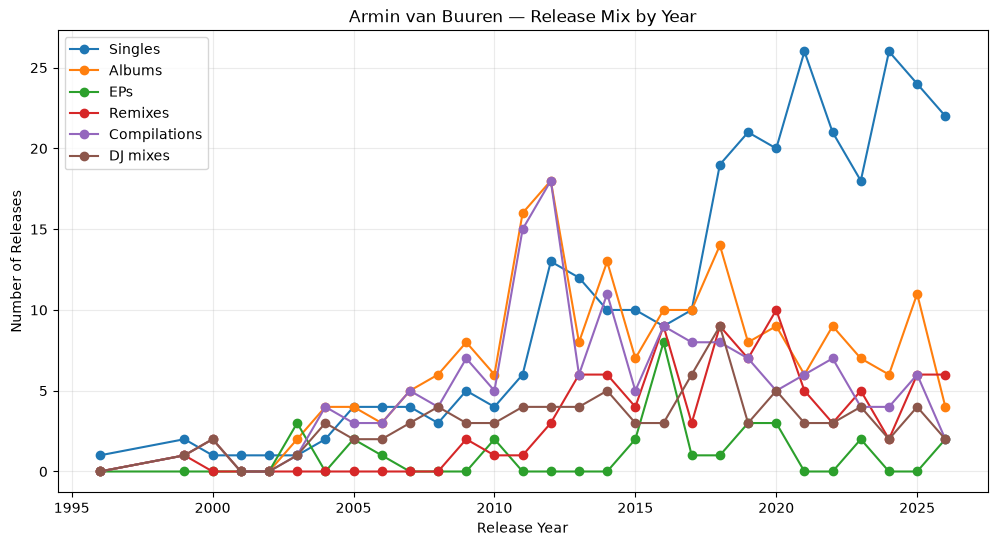

In [14]:
plt.figure(figsize=(12, 6))

for column, label in [
    ("singles", "Singles"),
    ("albums", "Albums"),
    ("eps", "EPs"),
    ("remixes", "Remixes"),
    ("compilations", "Compilations"),
    ("dj_mixes", "DJ mixes"),
]:
    plt.plot(
        release_yearly["release_year"],
        release_yearly[column],
        marker="o",
        label=label
    )

plt.title("Armin van Buuren — Release Mix by Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Releases")
plt.legend()
plt.grid(alpha=0.25)

plt.show()

In [15]:
release_yearly["core_release_share"] = (
    release_yearly["core_releases"]
    / release_yearly["total_releases"]
    * 100
)

release_yearly[
    ["release_year", "total_releases", "core_releases", "core_release_share"]
].round(1)

,release_year,total_releases,core_releases,core_release_share
0,1996,1,1,100.0
1,1999,3,1,33.3
2,2000,3,1,33.3
3,2001,1,1,100.0
4,2002,1,1,100.0
5,2003,6,5,83.3
6,2004,6,2,33.3
7,2005,10,7,70.0
8,2006,8,5,62.5
9,2007,9,4,44.4


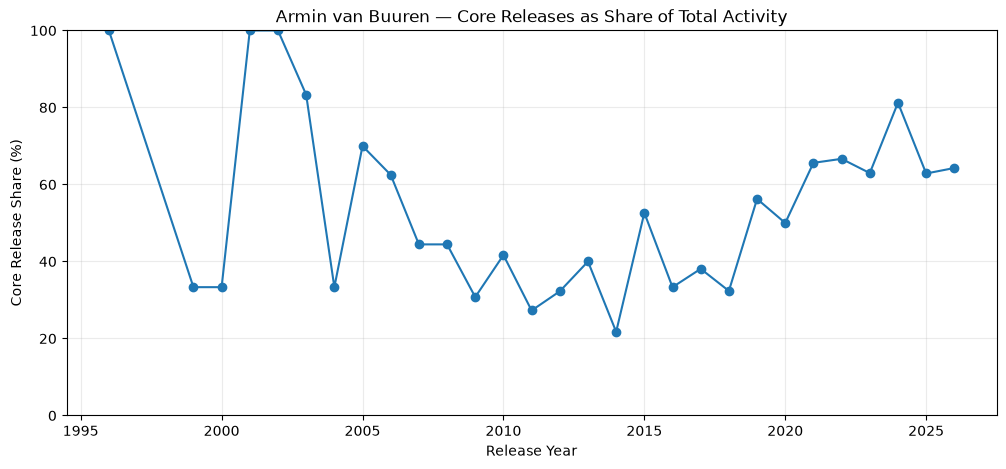

In [16]:
plt.figure(figsize=(12, 5))

plt.plot(
    release_yearly["release_year"],
    release_yearly["core_release_share"],
    marker="o"
)

plt.title("Armin van Buuren — Core Releases as Share of Total Activity")
plt.xlabel("Release Year")
plt.ylabel("Core Release Share (%)")
plt.ylim(0, 100)
plt.grid(alpha=0.25)

plt.show()

In [17]:
def assign_era(year):
    if year <= 2004:
        return "1996–2004: Early catalogue"
    elif year <= 2010:
        return "2005–2010: Expansion"
    elif year <= 2018:
        return "2011–2018: High-output diversified"
    else:
        return "2019–2026: Core-led mature"

release_yearly["career_era"] = (
    release_yearly["release_year"]
    .apply(assign_era)
)

era_summary = (
    release_yearly
    .groupby("career_era", sort=False)
    .agg(
        years=("release_year", "count"),
        total_releases=("total_releases", "sum"),
        core_releases=("core_releases", "sum"),
        singles=("singles", "sum"),
        albums=("albums", "sum"),
        eps=("eps", "sum"),
        remixes=("remixes", "sum"),
        compilations=("compilations", "sum"),
        dj_mixes=("dj_mixes", "sum"),
    )
    .reset_index()
)

era_summary["avg_releases_per_year"] = (
    era_summary["total_releases"] / era_summary["years"]
)

era_summary["core_release_share"] = (
    era_summary["core_releases"] / era_summary["total_releases"] * 100
)

era_summary.round(1)

,career_era,years,total_releases,core_releases,singles,albums,eps,remixes,compilations,dj_mixes,avg_releases_per_year,core_release_share
0,1996–2004: Early catalogue,7,21,12,9,9,3,1,8,7,3.0,57.1
1,2005–2010: Expansion,6,61,29,24,32,5,3,27,17,10.2,47.5
2,2011–2018: High-output diversified,8,197,67,89,96,12,41,80,38,24.6,34.0
3,2019–2026: Core-led mature,8,248,158,178,60,10,44,41,26,31.0,63.7


In [18]:
era_plot = era_summary[
    [
        "career_era",
        "avg_releases_per_year",
        "core_release_share"
    ]
].copy()

era_plot

,career_era,avg_releases_per_year,core_release_share
0,1996–2004: Early catalogue,3.000000,57.142857
1,2005–2010: Expansion,10.166667,47.540984
2,2011–2018: High-output diversified,24.625000,34.010152
3,2019–2026: Core-led mature,31.000000,63.709677


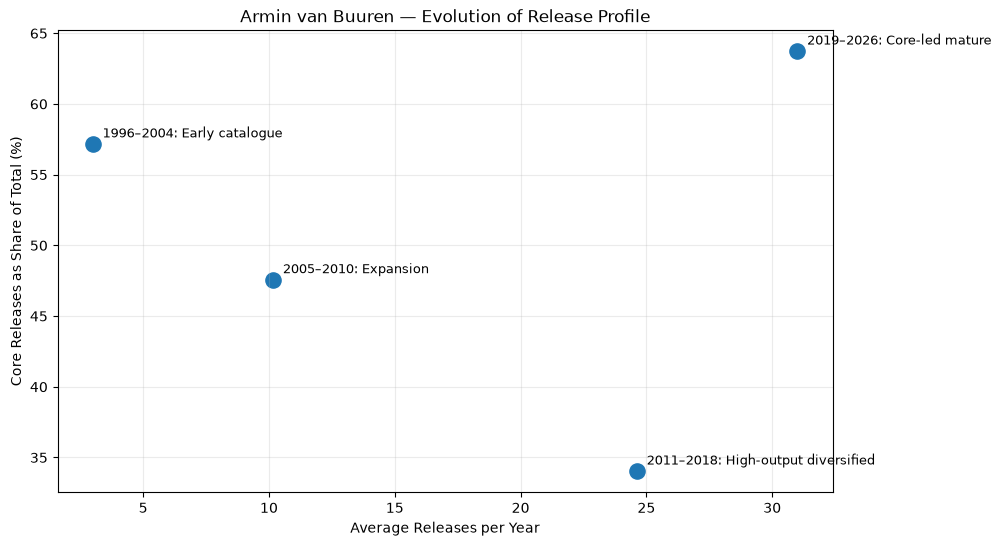

In [19]:
import matplotlib.pyplot as plt

plot_data = era_summary.copy()

plt.figure(figsize=(10, 6))

plt.scatter(
    plot_data["avg_releases_per_year"],
    plot_data["core_release_share"],
    s=120
)

for _, row in plot_data.iterrows():
    plt.annotate(
        row["career_era"],
        (
            row["avg_releases_per_year"],
            row["core_release_share"]
        ),
        xytext=(7, 5),
        textcoords="offset points",
        fontsize=9
    )

plt.title("Armin van Buuren — Evolution of Release Profile")
plt.xlabel("Average Releases per Year")
plt.ylabel("Core Releases as Share of Total (%)")
plt.grid(alpha=0.25)

plt.show()

In [20]:
tags = con.execute("""
    SELECT *
    FROM lastfm_artist_tags
    ORDER BY tag_rank
""").fetchdf()

tags

,artist_mbid,artist_name,tag_rank,tag_name
0,477b8c0c-c5fc-4ad2-b5b2-191f0bf2a9df,Armin van Buuren,1,trance
1,477b8c0c-c5fc-4ad2-b5b2-191f0bf2a9df,Armin van Buuren,2,progressive trance
2,477b8c0c-c5fc-4ad2-b5b2-191f0bf2a9df,Armin van Buuren,3,electronic
3,477b8c0c-c5fc-4ad2-b5b2-191f0bf2a9df,Armin van Buuren,4,vocal trance
4,477b8c0c-c5fc-4ad2-b5b2-191f0bf2a9df,Armin van Buuren,5,dance


In [21]:
similar = con.execute("""
    SELECT *
    FROM lastfm_similar_artists
    ORDER BY similar_artist_rank
""").fetchdf()

similar

,artist_mbid,artist_name,similar_artist_rank,similar_artist_name,similar_artist_url
0,477b8c0c-c5fc-4ad2-b5b2-191f0bf2a9df,Armin van Buuren,1,Ferry Corsten,https://www.last.fm/music/Ferry+Corsten
1,477b8c0c-c5fc-4ad2-b5b2-191f0bf2a9df,Armin van Buuren,2,Ben Gold,https://www.last.fm/music/Ben+Gold
2,477b8c0c-c5fc-4ad2-b5b2-191f0bf2a9df,Armin van Buuren,3,Andrew Rayel,https://www.last.fm/music/Andrew+Rayel
3,477b8c0c-c5fc-4ad2-b5b2-191f0bf2a9df,Armin van Buuren,4,Tiësto,https://www.last.fm/music/Ti%C3%ABsto
4,477b8c0c-c5fc-4ad2-b5b2-191f0bf2a9df,Armin van Buuren,5,Above & Beyond,https://www.last.fm/music/Above+&+Beyond


In [22]:
print("ARTIST POSITIONING")
print("=" * 50)

print("\nPrimary Last.fm tags:")
for _, row in tags.iterrows():
    print(f"{int(row['tag_rank'])}. {row['tag_name']}")

print("\nSimilar artists:")
for _, row in similar.iterrows():
    print(
        f"{int(row['similar_artist_rank'])}. "
        f"{row['similar_artist_name']}"
    )

ARTIST POSITIONING

Primary Last.fm tags:
1. trance
2. progressive trance
3. electronic
4. vocal trance
5. dance

Similar artists:
1. Ferry Corsten
2. Ben Gold
3. Andrew Rayel
4. Tiësto
5. Above & Beyond


In [3]:
import json
from pathlib import Path
import pandas as pd

bronze_file = Path("../data/bronze/musicbrainz/tiesto_release_groups.json")

with open(bronze_file, "r", encoding="utf-8") as f:
    tiesto_bronze = json.load(f)

print("Total Bronze records:", len(tiesto_bronze))

diagnostic = pd.DataFrame([
    {
        "title": r.get("title"),
        "primary_type": r.get("primary-type"),
        "first_release_date": r.get("first-release-date"),
        "secondary_types": r.get("secondary-types"),
        "artist_credit": [
            a.get("artist", {}).get("name")
            for a in r.get("artist-credit", [])
            if a.get("artist")
        ]
    }
    for r in tiesto_bronze
])

diagnostic.head(20)

Total Bronze records: 323


,title,primary_type,first_release_date,secondary_types,artist_credit
0,Break My Fall,Single,2007-07,[],"[Tiësto, BT]"
1,C’mon,Single,2010-05-11,[],"[Tiësto, Diplo]"
2,"Club Life, Volume Three: Stockholm",Album,2013-06-18,"[Compilation, DJ-mix]",[Tiësto]
3,Flight 643,Single,2001-04-30,[],[Tiësto]
4,In My Memory,Single,2002,[],"[Tiësto, Nicola Hitchcock]"
5,Copenhagen: Elements of Life World Tour,Album,2008-03-07,[Live],[Tiësto]
6,"Clublife, Vol. 5: China",Album,2017-10-06,"[Compilation, DJ-mix]",[Tiësto]
7,Urban Train,Single,2001-09-17,[],[Tiësto]
8,Just Be: Remixed,Album,2005-09-27,[Remix],[Tiësto]
9,The Motto (remixes),EP,2022-03-25,[Remix],"[Tiësto, Ava Max]"


In [4]:
print("PRIMARY TYPES")
display(
    diagnostic["primary_type"]
    .value_counts(dropna=False)
)

print("\nMISSING RELEASE DATES")
print(
    diagnostic["first_release_date"]
    .isna()
    .value_counts()
)

print("\nDATE EXAMPLES")
display(
    diagnostic[
        ["title", "primary_type", "first_release_date", "artist_credit"]
    ].head(30)
)

PRIMARY TYPES


primary_type
Single    253
Album      53
EP         17
Name: count, dtype: int64


MISSING RELEASE DATES
first_release_date
False    323
Name: count, dtype: int64

DATE EXAMPLES


,title,primary_type,first_release_date,artist_credit
0,Break My Fall,Single,2007-07,"[Tiësto, BT]"
1,C’mon,Single,2010-05-11,"[Tiësto, Diplo]"
2,"Club Life, Volume Three: Stockholm",Album,2013-06-18,[Tiësto]
3,Flight 643,Single,2001-04-30,[Tiësto]
4,In My Memory,Single,2002,"[Tiësto, Nicola Hitchcock]"
5,Copenhagen: Elements of Life World Tour,Album,2008-03-07,[Tiësto]
6,"Clublife, Vol. 5: China",Album,2017-10-06,[Tiësto]
7,Urban Train,Single,2001-09-17,[Tiësto]
8,Just Be: Remixed,Album,2005-09-27,[Tiësto]
9,The Motto (remixes),EP,2022-03-25,"[Tiësto, Ava Max]"
